# Exploratory Data Analysis (EDA)

This notebook audits the pre-pipeline research layer for the LendingClub-based human-AI decision support study. Its role is to justify the fixed feature set, verify the train-only difficulty construction, and export the processed dataset used downstream.

The EDA serves three purposes:

1. **Feature Space Construction** — justify the final feature list fixed in `feature_config.py`.
2. **Case Design Support** — derive difficulty tiers from train-only empirical base rates.
3. **Temporal Validity Checks** — verify stability and distribution shift without leaking post-2016 data into train-only transformations.

## Scope note

Missingness checks, univariate plots, and correlation analysis use the full dataset for descriptive context only. All transformations used in modeling and difficulty scoring like bin edges, smoothed base rates, and exported case difficulty variables, are estimated on the training set only, defined as loans issued before 2016, and then applied to later splits without re-fitting.

All exploratory figures are both saved to `codes/visualizations/` and displayed inline. 

Final paper figures are still generated separately by `codes/scripts/make_final_figures.py`.

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from pandas.api.types import is_numeric_dtype

np.random.seed(42)
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / 'artifacts').exists() and (candidate / 'codes').exists():
            return candidate
    raise RuntimeError('Could not locate repository root. Run from inside the capstone repo.')


ROOT = find_repo_root()
DATA_RAW = ROOT / 'data' / 'raw' / 'loan.csv'
DATA_PROC = ROOT / 'data' / 'processed' / 'loan_v1.csv'
ARTIFACTS = ROOT / 'artifacts'
FIGS_DIR = ROOT / 'codes' / 'visualizations'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

if str(ROOT / 'codes') not in sys.path:
    sys.path.append(str(ROOT / 'codes'))

from data_prep import load_and_clean, build_features
from feature_config import NUM_COLS, FEATURES, TARGET

print('ROOT     :', ROOT)
print('FIGS_DIR :', FIGS_DIR)
print('Working  :', Path.cwd())

ROOT     : /Users/annaasatryan/Desktop/capstone
FIGS_DIR : /Users/annaasatryan/Desktop/capstone/codes/visualizations
Working  : /Users/annaasatryan/Desktop/capstone/codes/notebooks


## Data loading

In [2]:
df = load_and_clean(DATA_RAW)
print('\nShape:', df.shape)
print('Columns:', len(df.columns))
print('\nTime range:', df['issue_d'].min(), '→', df['issue_d'].max())
print('\nDefault rate:', df[TARGET].mean())
print('\nMissing (top 10):')
print(df.isna().mean().sort_values(ascending=False).head(10))


Shape: (1300076, 131)
Columns: 131

Time range: 2007-06-01 00:00:00 → 2018-12-01 00:00:00

Default rate: 0.2008374895006138

Missing (top 10):
id                                            1.000000
url                                           1.000000
member_id                                     1.000000
orig_projected_additional_accrued_interest    0.997359
payment_plan_start_date                       0.995898
hardship_end_date                             0.995898
hardship_type                                 0.995898
hardship_reason                               0.995898
hardship_status                               0.995898
deferral_term                                 0.995898
dtype: float64


## Domain-driven candidate features

In [3]:
df = build_features(df)

candidate_features = [
    # loan structure
    'loan_amnt',
    'term',
    'int_rate',
    'installment',

    # borrower profile
    'log_annual_inc',
    'home_ownership',
    'purpose',

    # credit behavior
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'pub_rec_bankruptcies',
    'credit_history_years',
    'revol_util',
    'open_acc',
]

candidate_features = [c for c in candidate_features if c in df.columns]
print('\nInitial candidates:', candidate_features)


Initial candidates: ['loan_amnt', 'term', 'int_rate', 'installment', 'log_annual_inc', 'home_ownership', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec_bankruptcies', 'credit_history_years', 'revol_util', 'open_acc']


## Missingness and constant-feature filters

Missingness across candidate features is expected to be negligible for the retained decision-time variables. Simple downstream imputation (median for numeric variables and mode for categorical variables) is sufficient if missingness remains low.

The constant-feature filter is a safeguard to remove degenerate variables with no variance.

In [4]:
missing = df[candidate_features].isna().mean().sort_values(ascending=False)
print('\nMissingness:')
print(missing)

candidate_features = [c for c in candidate_features if missing[c] < 0.4]
print('\nAfter missing filter:', candidate_features)


def is_constant(series):
    return series.nunique(dropna=True) <= 1

candidate_features = [c for c in candidate_features if not is_constant(df[c])]
print('\nAfter constant filter:', candidate_features)


Missingness:
revol_util              6.184254e-04
pub_rec_bankruptcies    5.076626e-04
dti                     2.399860e-04
inq_last_6mths          7.691858e-07
loan_amnt               0.000000e+00
term                    0.000000e+00
int_rate                0.000000e+00
installment             0.000000e+00
log_annual_inc          0.000000e+00
home_ownership          0.000000e+00
purpose                 0.000000e+00
delinq_2yrs             0.000000e+00
credit_history_years    0.000000e+00
open_acc                0.000000e+00
dtype: float64

After missing filter: ['loan_amnt', 'term', 'int_rate', 'installment', 'log_annual_inc', 'home_ownership', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec_bankruptcies', 'credit_history_years', 'revol_util', 'open_acc']

After constant filter: ['loan_amnt', 'term', 'int_rate', 'installment', 'log_annual_inc', 'home_ownership', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec_bankruptcies', 'credit_history_years', 'revol_util'

Missingness across candidate features is negligible in the original EDA output, staying below 0.1% for all retained variables. This supports simple imputation in the modeling pipeline and avoids complicated missingness mechanisms that would be hard to explain to participants.

## Univariate analysis

For each candidate feature, this section prints default-rate summaries and saves/displays a paired diagnostic figure:

- default rate across bins or categories
- sample count across the same bins or categories

Numeric features are binned with quantiles for descriptive EDA only. These plots are not used to fit transformations. Train-derived binning for difficulty construction happens later.


--- loan_amnt ---
bin
(499.999, 6500.0]     0.159691
(6500.0, 10000.0]     0.176997
(10000.0, 15000.0]    0.208689
(15000.0, 21000.0]    0.228173
(21000.0, 40000.0]    0.234845
Name: target, dtype: float64


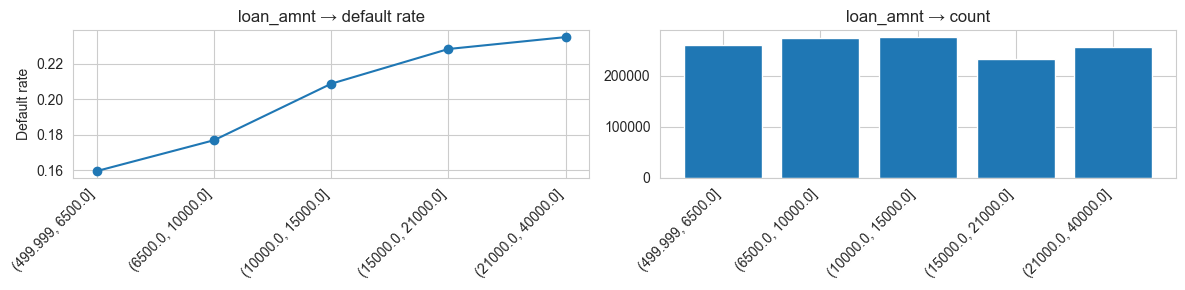


--- term ---
term
60 months    0.325730
36 months    0.161015
Name: target, dtype: float64


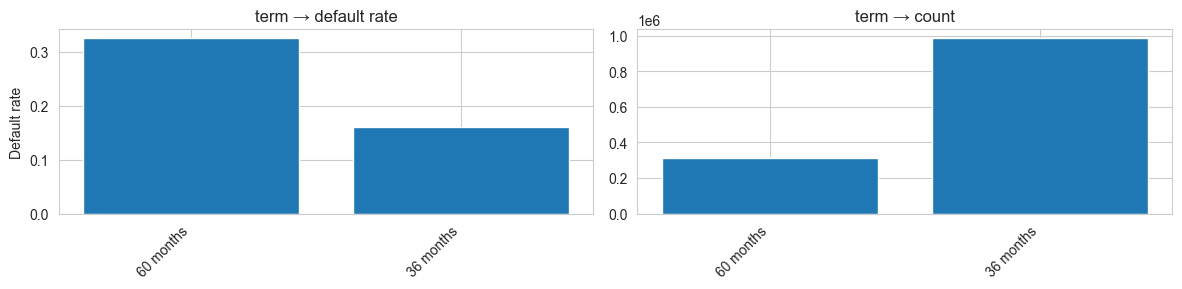


--- int_rate ---
bin
(5.308999999999999, 8.9]    0.067682
(8.9, 11.53]                0.138773
(11.53, 13.99]              0.194654
(13.99, 16.99]              0.251194
(16.99, 30.99]              0.360640
Name: target, dtype: float64


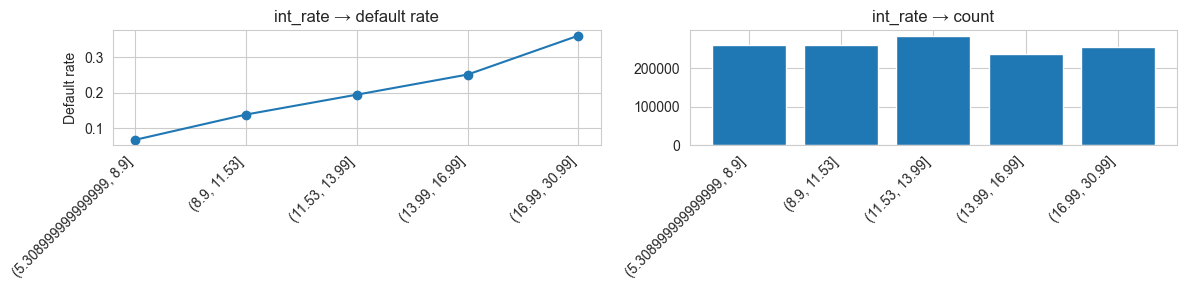


--- installment ---
bin
(4.928999999999999, 217.4]    0.154287
(217.4, 324.98]               0.191199
(324.98, 451.9]               0.217110
(451.9, 640.58]               0.219550
(640.58, 1719.83]             0.222087
Name: target, dtype: float64


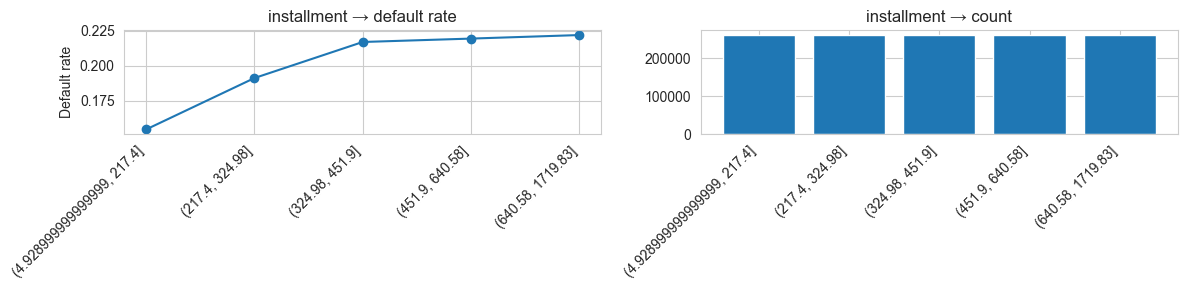


--- log_annual_inc ---
bin
(-0.001, 10.645]    0.236732
(10.645, 10.951]    0.217210
(10.951, 11.212]    0.204306
(11.212, 11.513]    0.185133
(11.513, 16.213]    0.158039
Name: target, dtype: float64


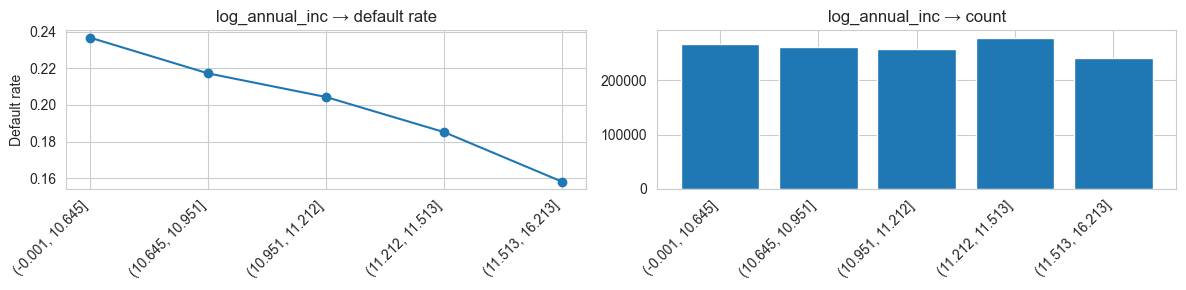


--- home_ownership ---
home_ownership
RENT        0.233765
OWN         0.207565
ANY         0.194757
OTHER       0.194245
MORTGAGE    0.173030
NONE        0.145833
Name: target, dtype: float64


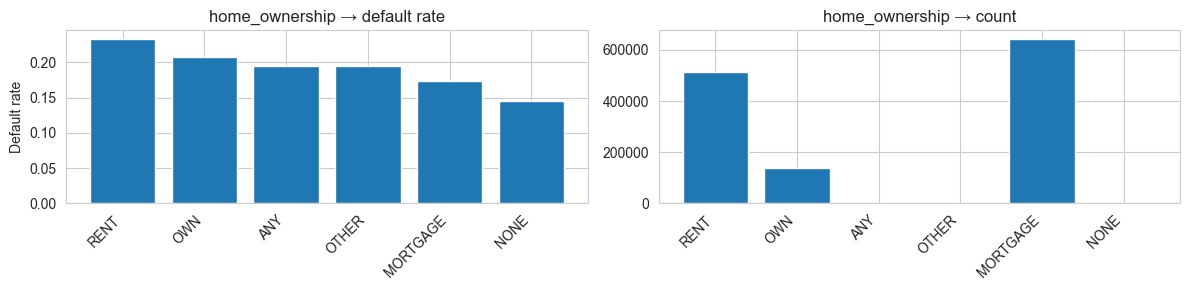


--- purpose ---
purpose
small_business        0.297468
moving                0.234409
medical               0.219064
house                 0.217167
debt_consolidation    0.212567
other                 0.211706
vacation              0.192396
major_purchase        0.187235
home_improvement      0.178531
credit_card           0.170267
car                   0.146388
Name: target, dtype: float64


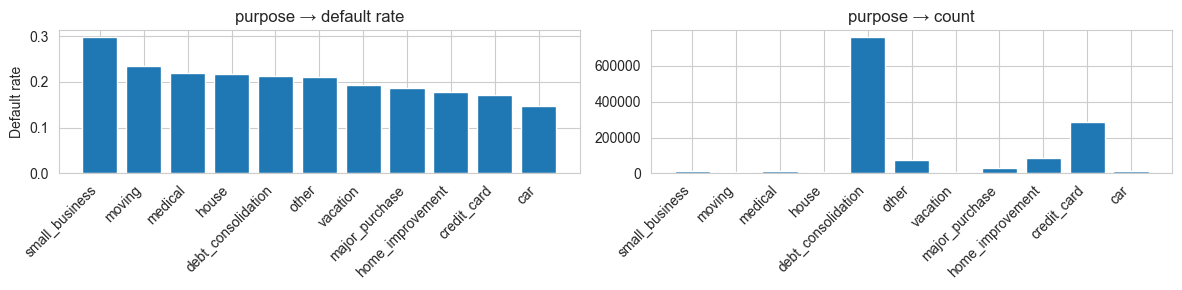


--- dti ---
bin
(-1.001, 10.5]    0.149530
(10.5, 15.33]     0.168552
(15.33, 19.98]    0.192321
(19.98, 25.68]    0.220839
(25.68, 999.0]    0.273090
Name: target, dtype: float64


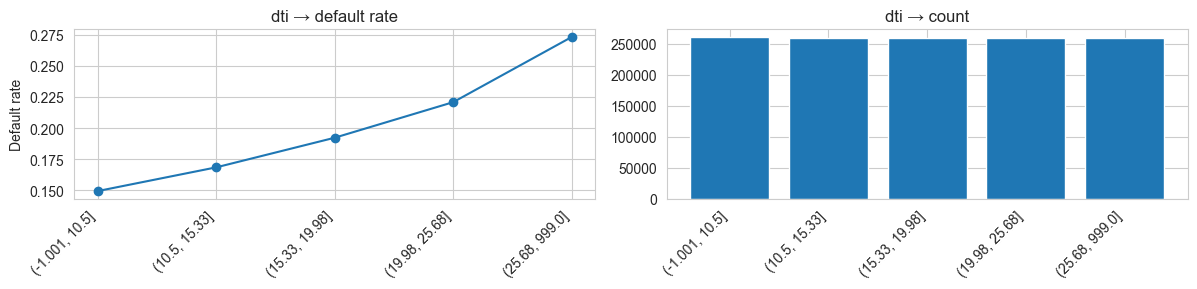


--- delinq_2yrs ---
bin
(-0.001, 39.0]    0.200837
Name: target, dtype: float64


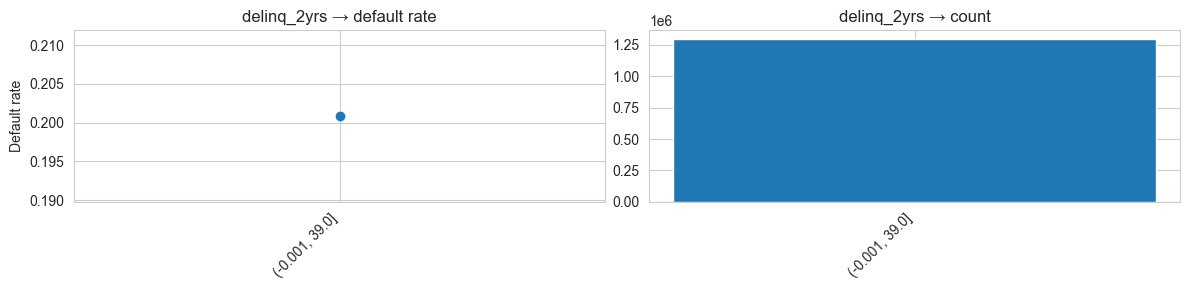


--- inq_last_6mths ---
bin
(-0.001, 1.0]    0.191730
(1.0, 8.0]       0.250167
Name: target, dtype: float64


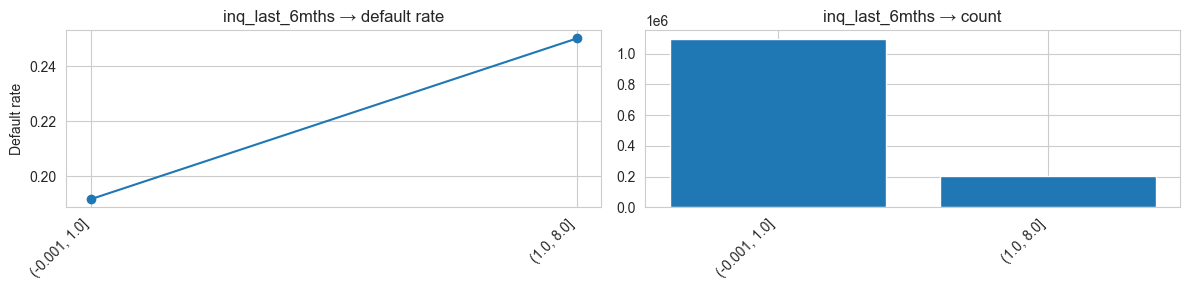


--- pub_rec_bankruptcies ---
bin
(-0.001, 12.0]    0.200853
Name: target, dtype: float64


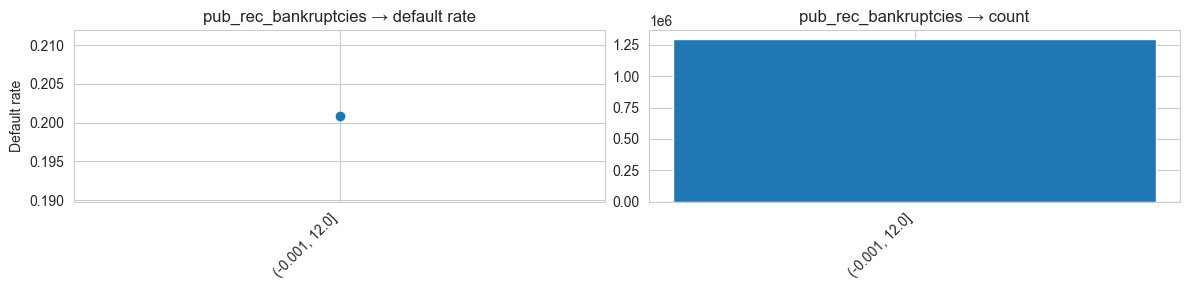


--- credit_history_years ---
bin
(2.9970000000000003, 10.42]    0.222339
(10.42, 13.328]                0.213994
(13.328, 16.498]               0.197919
(16.498, 21.582]               0.190151
(21.582, 83.25]                0.179733
Name: target, dtype: float64


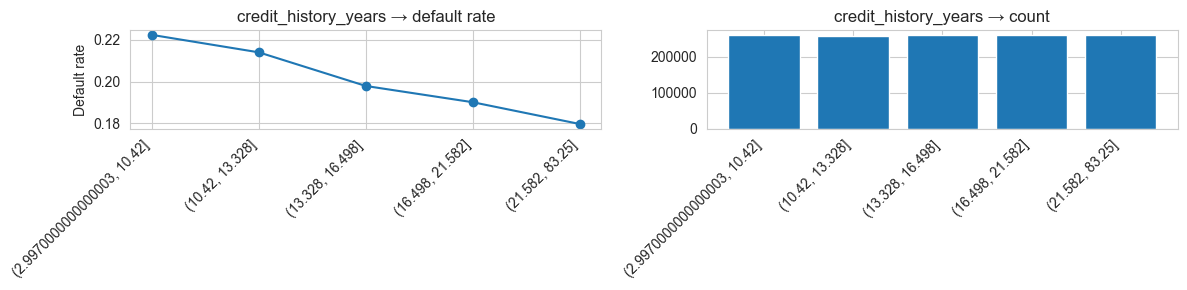


--- revol_util ---
bin
(-0.001, 29.2]    0.158371
(29.2, 45.1]      0.191146
(45.1, 59.4]      0.208644
(59.4, 75.1]      0.218329
(75.1, 892.3]     0.227809
Name: target, dtype: float64


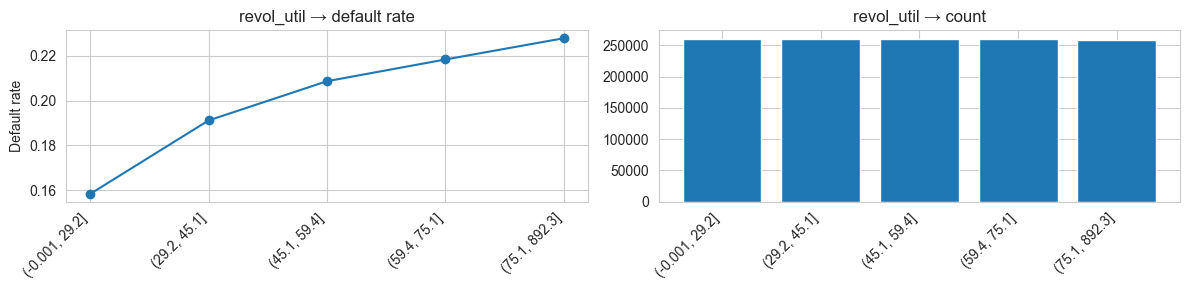


--- open_acc ---
bin
(-0.001, 7.0]    0.186035
(7.0, 9.0]       0.193504
(9.0, 12.0]      0.202872
(12.0, 15.0]     0.206650
(15.0, 90.0]     0.217280
Name: target, dtype: float64


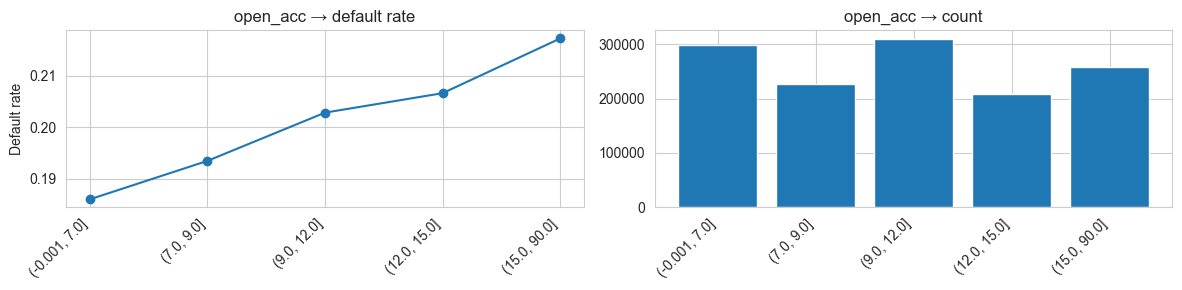

In [5]:
def analyze_feature(df_source, feature, bins=5):
    # Numeric qcut bins here are descriptive only; train-derived export bins are built later
    df_temp = df_source[[feature, TARGET]].dropna().copy()
    print(f'\n--- {feature} ---')

    if is_numeric_dtype(df_temp[feature]):
        df_temp['bin'] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')
        agg = df_temp.groupby('bin', observed=True)[TARGET].mean()
        counts = df_temp['bin'].value_counts().sort_index()
        labels = agg.index.astype(str)
        x = range(len(agg))

        print(agg)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
        ax1.plot(x, agg.values, marker='o')
        ax1.set_xticks(list(x))
        ax1.set_xticklabels(labels, rotation=45, ha='right')
        ax1.set_title(f'{feature} → default rate')
        ax1.set_ylabel('Default rate')

        ax2.bar(x, counts.values)
        ax2.set_xticks(list(x))
        ax2.set_xticklabels(counts.index.astype(str), rotation=45, ha='right')
        ax2.set_title(f'{feature} → count')

    else:
        agg = df_temp.groupby(feature, observed=True)[TARGET].mean().sort_values(ascending=False)
        counts = df_temp[feature].value_counts().reindex(agg.index)
        x = range(len(agg))

        print(agg)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
        ax1.bar(x, agg.values)
        ax1.set_xticks(list(x))
        ax1.set_xticklabels(agg.index.astype(str), rotation=45, ha='right')
        ax1.set_title(f'{feature} → default rate')
        ax1.set_ylabel('Default rate')

        ax2.bar(x, counts.values)
        ax2.set_xticks(list(x))
        ax2.set_xticklabels(counts.index.astype(str), rotation=45, ha='right')
        ax2.set_title(f'{feature} → count')

    plt.tight_layout()
    plt.show()


for feature in candidate_features:
    analyze_feature(df, feature)

The categorical summaries provide a direct interpretability check. `term`, `purpose`, and `home_ownership` all have human-readable meanings and can be shown in the DSS without requiring derived or post-outcome information.

## Categorical features vs target

In [6]:
print('\n=== Categorical Features vs Target ===')
cat_cols = ['purpose', 'home_ownership', 'term']

for col in cat_cols:
    print(f'\n--- {col} ---')
    summary = (
        df.groupby(col, observed=True)[TARGET]
        .agg(['mean', 'count'])
        .sort_values('mean', ascending=False)
    )
    print(summary)


=== Categorical Features vs Target ===

--- purpose ---
                        mean   count
purpose                             
small_business      0.297468   15010
moving              0.234409    9172
medical             0.219064   15023
house               0.217167    6967
debt_consolidation  0.212567  757591
other               0.211706   74934
vacation            0.192396    8732
major_purchase      0.187235   28328
home_improvement    0.178531   84495
credit_card         0.170267  285704
car                 0.146388   14120

--- home_ownership ---
                    mean   count
home_ownership                  
RENT            0.233765  515761
OWN             0.207565  139561
ANY             0.194757     267
OTHER           0.194245     139
MORTGAGE        0.173030  644300
NONE            0.145833      48

--- term ---
               mean   count
term                       
60 months  0.325730  314316
36 months  0.161015  985760


## Correlation check

The correlation matrix is used to identify redundancy between features rather than predictive strength. In particular, a strong relationship between `loan_amnt` and `installment` would indicate that `installment` is largely determined by loan structure variables and may distort interpretability if retained alongside them.

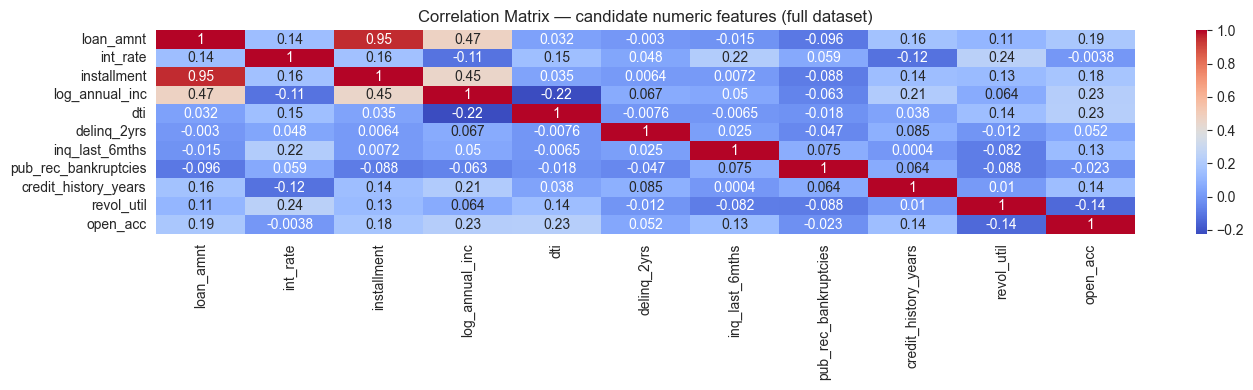

In [7]:
numeric_features = [c for c in candidate_features if is_numeric_dtype(df[c])]
corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix — candidate numeric features (full dataset)')
plt.tight_layout()
fig.savefig(FIGS_DIR / 'eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Interpretation: `loan_amnt` and `installment` are highly correlated, `installment` should be removed because it is functionally tied to loan amount, term, and interest rate. Keeping both would add redundancy without improving participant-facing clarity.

## Spearman rank correlations

Spearman rank correlation is used to assess monotonic relationships between numeric features and default risk. These results are used jointly with univariate analysis to guide feature selection, but they are not treated as a standalone feature-selection rule.

In [8]:
results = []

for col in NUM_COLS:
    valid = df[[col, TARGET]].dropna()
    corr_val, pval = spearmanr(valid[col], valid[TARGET])
    results.append((col, corr_val, pval))

spearman_df = pd.DataFrame(results, columns=['feature', 'spearman_corr', 'p_value'])
print(spearman_df.sort_values('spearman_corr', key=abs, ascending=False))

                feature  spearman_corr  p_value
1              int_rate       0.254142      0.0
3                   dti       0.108542      0.0
0             loan_amnt       0.070226      0.0
2        log_annual_inc      -0.067729      0.0
5            revol_util       0.060362      0.0
4  credit_history_years      -0.039248      0.0


Interpretation: the strongest monotonic signal should come from variables such as `int_rate`, followed by borrower burden measures such as `dti`. Smaller but directionally meaningful signals can still be retained if they are interpretable and non-redundant.

## Feature interaction check

This interaction analysis uses training data only, because it informs the train-derived case difficulty construction.

The goal is not to build an interaction-heavy predictive model. The goal is to check whether risk varies meaningfully across a compact multidimensional grid of interest rate, DTI, and income. If the grid is approximately additive, the difficulty construction is conservative; if there is super-additivity, the multidimensional construction is even more justified.

=== RATE × DTI DEFAULT RATES (train) ===

rate_q        Low rate  Med-low rate  Med-high rate  High rate
dti_q                                                         
Low DTI          0.055         0.118          0.173      0.260
Med-low DTI      0.064         0.133          0.193      0.298
Med-high DTI     0.077         0.151          0.215      0.326
High DTI         0.092         0.172          0.248      0.378

=== RATE × INCOME DEFAULT RATES (train) ===

rate_q        Low rate  Med-low rate  Med-high rate  High rate
inc_q                                                         
Low income       0.091         0.161          0.227      0.334
Med-low inc      0.075         0.144          0.218      0.346
Med-high inc     0.066         0.138          0.202      0.324
High income      0.056         0.125          0.179      0.279


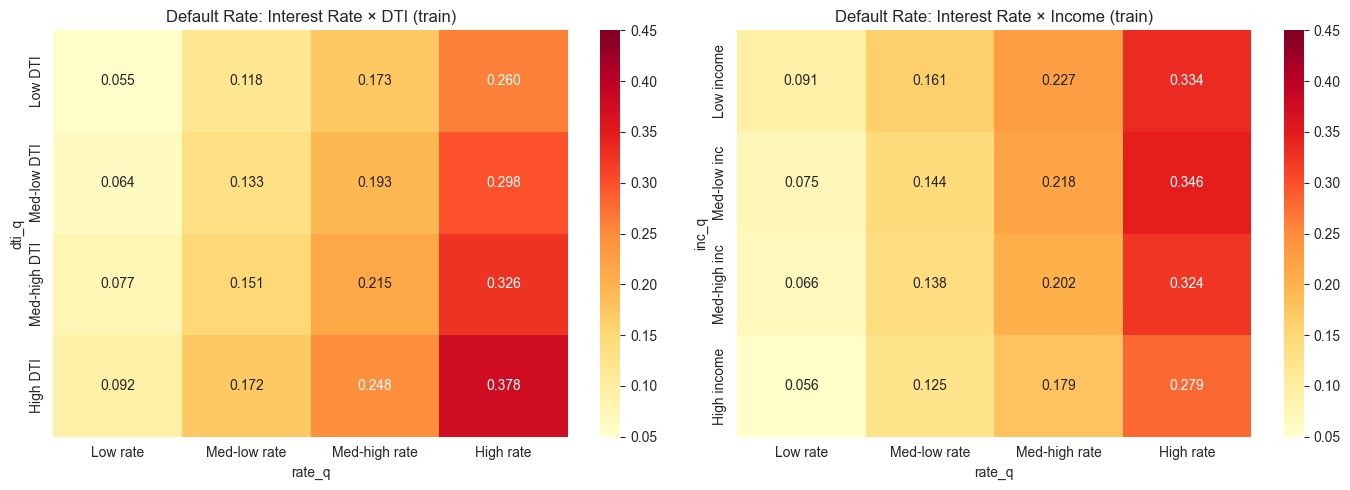


=== INTERACTION STRENGTH ===
Additive prediction (high rate + high DTI): 0.3825
Actual observed (high rate + high DTI): 0.3780
Interaction effect (actual - additive): -0.0045

→ Approximately additive. 3D construction conservative but defensible.


In [9]:
train_interaction = df[df['issue_d'] < '2016-01-01'].copy()

train_interaction['rate_q'] = pd.qcut(
    train_interaction['int_rate'],
    q=4,
    labels=['Low rate', 'Med-low rate', 'Med-high rate', 'High rate'],
)
train_interaction['dti_q'] = pd.qcut(
    train_interaction['dti'],
    q=4,
    labels=['Low DTI', 'Med-low DTI', 'Med-high DTI', 'High DTI'],
)
train_interaction['inc_q'] = pd.qcut(
    train_interaction['log_annual_inc'],
    q=4,
    labels=['Low income', 'Med-low inc', 'Med-high inc', 'High income'],
)

rate_dti_grid = train_interaction.pivot_table(
    values=TARGET,
    index='dti_q',
    columns='rate_q',
    aggfunc='mean',
    observed=True,
).round(3)

rate_inc_grid = train_interaction.pivot_table(
    values=TARGET,
    index='inc_q',
    columns='rate_q',
    aggfunc='mean',
    observed=True,
).round(3)

print('=== RATE × DTI DEFAULT RATES (train) ===\n')
print(rate_dti_grid.to_string())
print('\n=== RATE × INCOME DEFAULT RATES (train) ===\n')
print(rate_inc_grid.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(rate_dti_grid, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0], vmin=0.05, vmax=0.45)
axes[0].set_title('Default Rate: Interest Rate × DTI (train)')
sns.heatmap(rate_inc_grid, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1], vmin=0.05, vmax=0.45)
axes[1].set_title('Default Rate: Interest Rate × Income (train)')
plt.tight_layout()
fig.savefig(FIGS_DIR / 'eda_feature_interactions.png', dpi=150, bbox_inches='tight')
plt.show()

marginal_rate = train_interaction.groupby('rate_q', observed=True)[TARGET].mean()
marginal_dti = train_interaction.groupby('dti_q', observed=True)[TARGET].mean()
global_mean = train_interaction[TARGET].mean()

additive_prediction = global_mean + (marginal_rate.iloc[-1] - global_mean) + (marginal_dti.iloc[-1] - global_mean)
actual_joint = rate_dti_grid.iloc[-1, -1]

print('\n=== INTERACTION STRENGTH ===')
print(f'Additive prediction (high rate + high DTI): {additive_prediction:.4f}')
print(f'Actual observed (high rate + high DTI): {actual_joint:.4f}')
print(f'Interaction effect (actual - additive): {actual_joint - additive_prediction:+.4f}')

if abs(actual_joint - additive_prediction) > 0.02:
    print('\n→ Super-additive interaction. 3D difficulty construction justified.')
else:
    print('\n→ Approximately additive. 3D construction conservative but defensible.')

Feature interaction analysis in the original notebook found the high-rate/high-DTI cell to be approximately additive rather than strongly super-additive. That means a 3D difficulty grid is conservative but still defensible: it captures stable joint-risk structure without claiming complex nonlinear interaction effects.

## Feature decisions

`feature_config.py` is authoritative for the final modeling feature set. This EDA section independently derives the same feature set and asserts that the notebook and config are synchronized.

In [10]:
redundant_features = ['installment']
low_signal_features = ['delinq_2yrs', 'pub_rec_bankruptcies']
parsimony_exclusions = ['inq_last_6mths', 'open_acc']

remove_features = set(redundant_features + low_signal_features + parsimony_exclusions)
final_features = [f for f in candidate_features if f not in remove_features]

print('Derived final features:', final_features)

assert set(final_features) == set(FEATURES), (
    f'feature_config.py is out of sync!\n'
    f'  EDA derives: {sorted(final_features)}\n'
    f'  Config has : {sorted(FEATURES)}\n'
    'Update feature_config.py to match.'
)

print('feature_config.py consistent with EDA derivation')

Derived final features: ['loan_amnt', 'term', 'int_rate', 'log_annual_inc', 'home_ownership', 'purpose', 'dti', 'credit_history_years', 'revol_util']
feature_config.py consistent with EDA derivation


## Feature Selection and Justification

Each retained feature must satisfy all four criteria:

1. **Available at decision time**  
   Features must be observable before the lending decision. Post-outcome variables are excluded to avoid leakage.

2. **Interpretable**  
   Features must be understandable to human participants in the DSS.

3. **Stable relationship with target**  
   The feature should show a consistent, preferably monotonic, relationship with default risk in EDA.

4. **Non-redundant**  
   Features that are highly correlated or functionally derived from others are removed.

### Removed feature groups

**Redundant feature**

- `installment` removed because it is highly correlated with `loan_amnt` and is functionally determined by loan amount, term, and interest rate.

**Near-no-signal features**

- `delinq_2yrs` removed.
- `pub_rec_bankruptcies` removed.

These showed flat or near-constant default-rate patterns and added noise without meaningful discriminative value.

**Moderate-signal but excluded for parsimony**

- `inq_last_6mths` removed because it has limited resolution and a weak/unstable relationship with default risk.
- `open_acc` removed because it has a weak monotonic trend and overlaps conceptually with broader credit-capacity indicators.

### Final retained feature groups

**Loan structure**

- `loan_amnt`
- `term`
- `int_rate`

**Borrower profile**

- `log_annual_inc`
- `home_ownership`
- `purpose`

**Credit behavior**

- `dti`
- `credit_history_years`
- `revol_util`

The final feature set deliberately favors compactness and interpretability over maximum predictive complexity. This helps isolate the effect of human-AI interaction protocols rather than feature overload.

## Temporal split and target drift

The study uses a fixed temporal split:

- **Train-side period:** loans issued before 2016
- **Test-side period:** loans issued in 2016 or later

This split is deliberately chronological. It avoids training on future loans and tests whether the model/difficulty construction remains usable under realistic temporal distribution shift.

In [11]:
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
split_date = pd.Timestamp('2016-01-01')

train = df[df['issue_d'] < split_date].copy()
test = df[df['issue_d'] >= split_date].copy()

print('\nTrain default:', train[TARGET].mean())
print('Test default:', test[TARGET].mean())
print('Shift:', test[TARGET].mean() - train[TARGET].mean())


Train default: 0.18448195087671354
Test default: 0.228741694836228
Shift: 0.04425974395951446


Temporal distribution shift is expected: a later lending period may have a different default-rate level than the training period. This motivates calibrated probabilities and careful post-2016 evaluation rather than relying only on in-period apparent fit.

## Default rate over time

This plot checks temporal drift in both default rate and loan volume. The vertical line marks the pre-2016 versus post-2016 boundary.

The plot is descriptive, but it supports the main design choice: use pre-2016 data to estimate training-side transformations, then evaluate later periods without re-fitting.

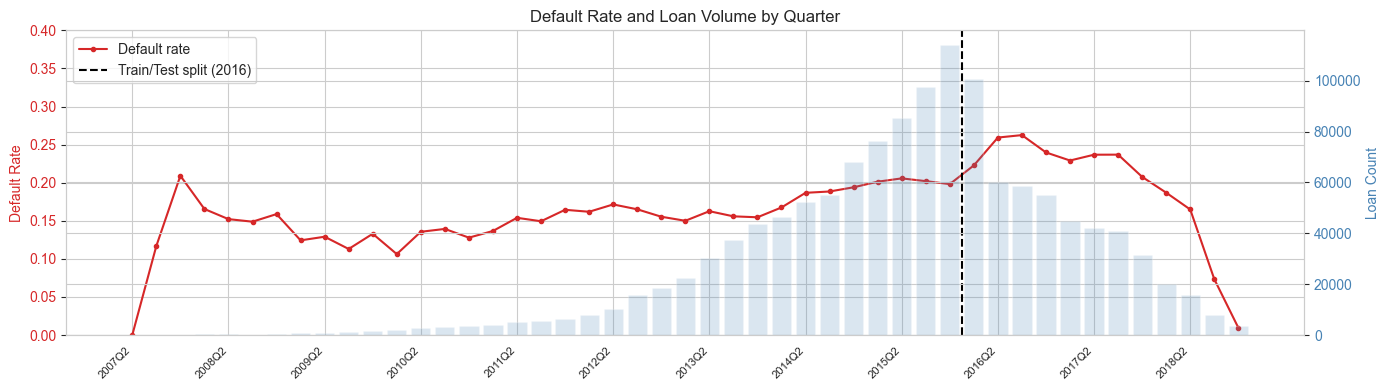

=== DEFAULT RATE BY YEAR ===

            default_rate  n_loans
issue_year                       
2007            0.177489      231
2008            0.158936     1466
2009            0.125622     4418
2010            0.129334    11134
2011            0.152639    21161
2012            0.162405    52560
2013            0.155986   134147
2014            0.185378   221342
2015            0.201555   373193
2016            0.242661   274498
2017            0.228912   158777
2018            0.147129    47149

Train period mean: 0.1845
Test period mean:  0.2287


In [12]:
df['issue_quarter'] = df['issue_d'].dt.to_period('Q')

quarterly = (
    df.groupby('issue_quarter')[TARGET]
    .agg(default_rate='mean', n_loans='count')
    .reset_index()
    .sort_values('issue_quarter')
)

quarterly['issue_quarter_label'] = quarterly['issue_quarter'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 4))
x = range(len(quarterly))

color_rate = '#d62728'
ax1.plot(
    x,
    quarterly['default_rate'],
    color=color_rate,
    linewidth=1.5,
    marker='o',
    markersize=3,
    label='Default rate',
)
ax1.set_ylabel('Default Rate', color=color_rate)
ax1.tick_params(axis='y', labelcolor=color_rate)
ax1.set_ylim(0, 0.40)

ax2 = ax1.twinx()
ax2.bar(x, quarterly['n_loans'], alpha=0.2, color='steelblue', label='Loan count')
ax2.set_ylabel('Loan Count', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

split_period = pd.Period('2016Q1', freq='Q')
train_end_idx = quarterly[quarterly['issue_quarter'] < split_period].index.max()

if pd.notna(train_end_idx):
    split_x = quarterly.index.get_loc(train_end_idx) + 0.5
    ax1.axvline(
        split_x,
        color='black',
        linestyle='--',
        linewidth=1.5,
        label='Train/Test split (2016)',
    )

tick_positions = list(range(0, len(quarterly), 4))
tick_labels = quarterly['issue_quarter_label'].iloc[tick_positions]
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
ax1.set_title('Default Rate and Loan Volume by Quarter')
ax1.legend(loc='upper left')

plt.tight_layout()
fig.savefig(FIGS_DIR / 'eda_default_rate_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== DEFAULT RATE BY YEAR ===\n')
df['issue_year'] = df['issue_d'].dt.year
yearly = df.groupby('issue_year')[TARGET].agg(default_rate='mean', n_loans='count')
print(yearly.to_string())

train_mask = df['issue_d'] < split_date
test_mask = df['issue_d'] >= split_date
print(f"\nTrain period mean: {df.loc[train_mask, TARGET].mean():.4f}")
print(f"Test period mean:  {df.loc[test_mask, TARGET].mean():.4f}")

## Binning: train-derived edges

Bin edges are computed on the training set only. The same edges are then applied to train, test, and the full export dataset.

This matters because re-fitting bin edges on the full dataset would leak post-2016 distributional information into the pre-modeling research layer. The edge endpoints are opened to `-inf` and `inf` so later-period values outside the training range are still assigned bins.

In [13]:
bin_edges = {}

_, edges = pd.qcut(train['log_annual_inc'], q=5, retbins=True, duplicates='drop')
bin_edges['income'] = edges

_, edges = pd.qcut(train['loan_amnt'], q=4, retbins=True, duplicates='drop')
bin_edges['loan'] = edges

_, edges = pd.qcut(train['int_rate'], q=4, retbins=True, duplicates='drop')
bin_edges['rate'] = edges

_, edges = pd.qcut(train['dti'], q=4, retbins=True, duplicates='drop')
bin_edges['dti'] = edges


def apply_bins(df_source, bin_edges):
    df_out = df_source.copy()

    def open_edges(edges):
        e = edges.copy()
        e[0] = -np.inf
        e[-1] = np.inf
        return e

    df_out['income_bin'] = pd.cut(df_out['log_annual_inc'], bins=open_edges(bin_edges['income']), include_lowest=True)
    df_out['loan_bin'] = pd.cut(df_out['loan_amnt'], bins=open_edges(bin_edges['loan']), include_lowest=True)
    df_out['rate_bin'] = pd.cut(df_out['int_rate'], bins=open_edges(bin_edges['rate']), include_lowest=True)
    df_out['dti_bin'] = pd.cut(df_out['dti'], bins=open_edges(bin_edges['dti']), include_lowest=True)
    return df_out


train = apply_bins(train, bin_edges)
test = apply_bins(test, bin_edges)
df = apply_bins(df, bin_edges)

## Bin reliability and stability

This section checks two things:

1. **Reliability:** train-side default rates and counts inside each bin.
2. **Stability:** whether the same bin ordering broadly persists in the post-2016 test-side period.

The expected pattern is level shift, not necessarily identical rates. A higher post-2016 default rate is acceptable; the key question is whether the bins preserve directional signal.

In [14]:
for col in ['income_bin', 'loan_bin', 'rate_bin', 'dti_bin']:
    print(f'\n=== {col} ===')
    print(train.groupby(col, observed=True)[TARGET].agg(['mean', 'count']))

print('\n=== Train/test stability ===')
for col in ['income_bin', 'loan_bin', 'rate_bin', 'dti_bin']:
    print(f'\n=== {col} ===')
    print('Train:')
    print(train.groupby(col, observed=True)[TARGET].mean())
    print('Test:')
    print(test.groupby(col, observed=True)[TARGET].mean())


=== income_bin ===
                      mean   count
income_bin                        
(-inf, 10.645]    0.215146  174305
(10.645, 10.915]  0.202768  154842
(10.915, 11.184]  0.190546  167057
(11.184, 11.493]  0.169284  161557
(11.493, inf]     0.142886  161891

=== loan_bin ===
                        mean   count
loan_bin                            
(-inf, 8000.0]      0.145539  222380
(8000.0, 12000.0]   0.177131  189137
(12000.0, 20000.0]  0.204499  233409
(20000.0, inf]      0.215263  174726

=== rate_bin ===
                    mean   count
rate_bin                        
(-inf, 9.76]    0.068912  205698
(9.76, 12.99]   0.142919  220397
(12.99, 15.88]  0.209188  190412
(15.88, inf]    0.323439  203145

=== dti_bin ===
                   mean   count
dti_bin                        
(-inf, 11.78]  0.137226  204997
(11.78, 17.5]  0.163951  205147
(17.5, 23.76]  0.193332  204777
(23.76, inf]   0.243517  204729

=== Train/test stability ===

=== income_bin ===
Train:
income_bin
(-

## Case difficulty construction

Difficulty construction design choices:

- **Model-independent:** uses empirical base rates, not model predictions.
- **Multidimensional:** uses `rate_bin × dti_bin × income_bin`.
- **Bayesian-smoothed:** shrinks sparse-bin estimates toward the training global mean.
- **Train-only:** all bin statistics are estimated on the training set and then mapped to the full dataset without re-fitting.

Difficulty is defined as closeness to maximum uncertainty. A base rate near 0.5 is considered harder; a base rate near 0 or 1 is considered easier.

In [15]:
# Difficulty construction is based only on train-estimated bin rates
# It does not use model predictions, validation outcomes, or post-2016 re-fitting
BIN_COLS = ['rate_bin', 'dti_bin', 'income_bin']

bin_stats = (
    train.groupby(BIN_COLS, observed=True)
    .agg(bin_count=(TARGET, 'size'), bin_mean=(TARGET, 'mean'))
)

global_mean = train[TARGET].mean()
alpha = 50

bin_stats['smoothed_rate'] = (
    (bin_stats['bin_count'] * bin_stats['bin_mean'] + alpha * global_mean)
    / (bin_stats['bin_count'] + alpha)
)

bin_rates = bin_stats['smoothed_rate']


def map_base_rate(df_source, bin_rates, global_mean):
    idx = pd.MultiIndex.from_frame(df_source[BIN_COLS])
    return np.array(idx.map(bin_rates).fillna(global_mean), dtype=float)


train['case_base_rate'] = map_base_rate(train, bin_rates, global_mean)
df['case_base_rate'] = map_base_rate(df, bin_rates, global_mean)

df['difficulty_score'] = np.clip(1 - np.abs(df['case_base_rate'] - 0.5) / 0.5, 0, 1)
df['difficulty_tier'] = pd.cut(
    df['difficulty_score'],
    bins=[0, 0.33, 0.66, 1],
    labels=['easy', 'medium', 'hard'],
    include_lowest=True,
)

print('\n=== Difficulty sanity check ===')
print(df.groupby('difficulty_tier', observed=True)[TARGET].mean())
print('\n=== Counts per tier ===')
print(df['difficulty_tier'].value_counts().sort_index())
print('\n=== Bin coverage ===')
print('Missing rate:', df['case_base_rate'].isna().mean())


=== Difficulty sanity check ===
difficulty_tier
easy      0.115213
medium    0.253935
hard      0.384850
Name: target, dtype: float64

=== Counts per tier ===
difficulty_tier
easy      640042
medium    509118
hard      150916
Name: count, dtype: int64

=== Bin coverage ===
Missing rate: 0.0


Multiple formulations of case difficulty were considered, including distance from empirical base rate and distribution-based quantile approaches. The final definition is retained because it gives monotonic separation in observed default rates across tiers while preserving sufficient sample size per tier.

The hard tier can be smaller than easy/medium because high-uncertainty cases are rarer in the data. That imbalance is preserved to maintain realism instead of forcing artificial tier balance.

## Smoothing sensitivity analysis

The smoothing parameter `alpha` controls shrinkage toward the training global mean. This section checks whether difficulty-tier counts are stable across plausible alpha values.

Large changes would imply that tier assignment is highly sensitive to smoothing; stable counts support the selected value.

In [16]:
global_mean_train = train[TARGET].mean()

print('Smoothing sensitivity (tier counts across alpha values):\n')
print(f"{'alpha':>6} {'easy':>9} {'medium':>9} {'hard':>9}")

for alpha_test in [10, 25, 50, 100, 200]:
    bs = (
        train.groupby(BIN_COLS, observed=True)
        .agg(bin_count=(TARGET, 'size'), bin_mean=(TARGET, 'mean'))
    )
    bs['smoothed'] = (
        (bs['bin_count'] * bs['bin_mean'] + alpha_test * global_mean_train)
        / (bs['bin_count'] + alpha_test)
    )

    idx = pd.MultiIndex.from_frame(df[BIN_COLS])
    base = np.array(idx.map(bs['smoothed']).fillna(global_mean_train), dtype=float)
    difficulty = np.clip(1 - np.abs(base - 0.5) / 0.5, 0, 1)
    tiers = pd.cut(difficulty, bins=[0, 0.33, 0.66, 1], labels=['easy', 'medium', 'hard'], include_lowest=True)
    counts = pd.Series(tiers).value_counts().reindex(['easy', 'medium', 'hard']).fillna(0).astype(int)

    print(f"{alpha_test:>6} {counts['easy']:>9,} {counts['medium']:>9,} {counts['hard']:>9,}")

Smoothing sensitivity (tier counts across alpha values):

 alpha      easy    medium      hard
    10   640,042   509,118   150,916
    25   640,042   509,118   150,916
    50   640,042   509,118   150,916
   100   640,042   509,118   150,916
   200   640,042   520,391   139,643


## DSS structure and final dataset export

This section constructs two downstream views:

- a modeling dataset with the final feature set and target
- an experiment-facing structure with binned variables and difficulty tier

The exported processed dataset includes the final modeling features, target, issue date, train-derived base-rate difficulty variables, and a deterministic `case_id`.

In [ ]:
model_df = df[FEATURES + [TARGET]].dropna().copy()
experiment_df = df[
    [
        'loan_bin', 'rate_bin', 'income_bin', 'dti_bin',
        'home_ownership', 'purpose', TARGET, 'difficulty_tier',
    ]
].dropna().copy()

print('\nModel dataset:', model_df.shape)
print('Experiment dataset:', experiment_df.shape)

# Final dataset export

df_final = df[FEATURES + [TARGET, 'issue_d']].copy()
df_final['case_base_rate'] = df['case_base_rate']
df_final['difficulty_score'] = df['difficulty_score']
df_final['difficulty_tier'] = df['difficulty_tier']
df_final = df_final.dropna().copy()

_sort_cols = [
    'issue_d',
    'loan_amnt',
    'int_rate',
    'dti',
    'revol_util',
    'log_annual_inc',
    'credit_history_years',
]

df_final = df_final.sort_values(_sort_cols, kind='mergesort').reset_index(drop=True)
df_final['case_id'] = df_final.index

df_final.to_csv(DATA_PROC, index=False)
print('Saved:', DATA_PROC)


Model dataset: (1298960, 10)
Experiment dataset: (1299764, 8)
Saved: /Users/annaasatryan/Desktop/capstone/data/processed/loan_v1.csv


## Processed dataset validation

The export must be reproducible and structurally safe for downstream modeling and candidate-pool construction. The checks below enforce required columns, unique/contiguous `case_id`, valid difficulty scores, and non-missing difficulty tiers.

In [18]:
check = pd.read_csv(DATA_PROC)

required_cols = FEATURES + [
    TARGET,
    'issue_d',
    'case_base_rate',
    'difficulty_score',
    'difficulty_tier',
    'case_id',
]

missing = [c for c in required_cols if c not in check.columns]
assert not missing, f'Missing columns: {missing}'
assert check['case_id'].is_unique, 'case_id is not unique'
assert check['case_id'].min() == 0, 'case_id should start at 0'
assert check['case_id'].max() == len(check) - 1, 'case_id should be contiguous'
assert check['difficulty_score'].between(0, 1).all(), 'difficulty_score outside [0, 1]'
assert check['difficulty_tier'].notna().all(), 'Missing difficulty_tier'

print('Processed dataset validation passed.')
print('Shape:', check.shape)
print('Difficulty counts:')
print(check['difficulty_tier'].value_counts().sort_index())

Processed dataset validation passed.
Shape: (1298960, 15)
Difficulty counts:
difficulty_tier
easy      639757
hard      150847
medium    508356
Name: count, dtype: int64
